In [19]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import os
import glob
from torch.utils.data import Dataset
from PIL import Image
import os
from torchvision.datasets import ImageFolder
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("syedhashirali260/tomato-leaf-disease-dataset-6-classes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomato-leaf-disease-dataset-6-classes' dataset.
Path to dataset files: /kaggle/input/tomato-leaf-disease-dataset-6-classes


In [50]:

dir_path =os.path.join(path,"Tomato_Leaf_Dataset")
all_images = glob.glob(os.path.join(dir_path, "*", "*.jpg"))
print(f"Total images: {len(all_images)}")

# Extract class names
labels = [os.path.basename(os.path.dirname(img)).replace("Tomato_", "") for img in all_images]
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"\nTraining set: {len(train_paths)} images ({len(train_paths)/len(all_images)*100:.1f}%)")
print(f"Testing set: {len(test_paths)} images ({len(test_paths)/len(all_images)*100:.1f}%)")


Total images: 7200

Training set: 5760 images (80.0%)
Testing set: 1440 images (20.0%)


In [52]:
class TomatoDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

        # Create class to index mapping
        self.classes = sorted(set(labels))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.targets = [self.class_to_idx[label] for label in labels]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.targets[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# 3. Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Create datasets
train_dataset = TomatoDataset(train_paths, train_labels, transform=train_transform)
test_dataset = TomatoDataset(test_paths, test_labels, transform=test_transform)

print(f"\nDataset created:")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

# 5. Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nDataloaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Dataset created:
Train samples: 5760
Test samples: 1440
Classes: ['Early_blight', 'Healthy', 'leaf_late_blight', 'leaf_yellow_curl_virus', 'mold_leaf', 'septora_leaf_spot']

Dataloaders created:
Train batches: 180
Test batches: 45


In [53]:
def img_denormlized(img):
  mean=[0.485, 0.456, 0.406]
  std=[0.229, 0.224, 0.225]
  img=img*std+mean
  return img

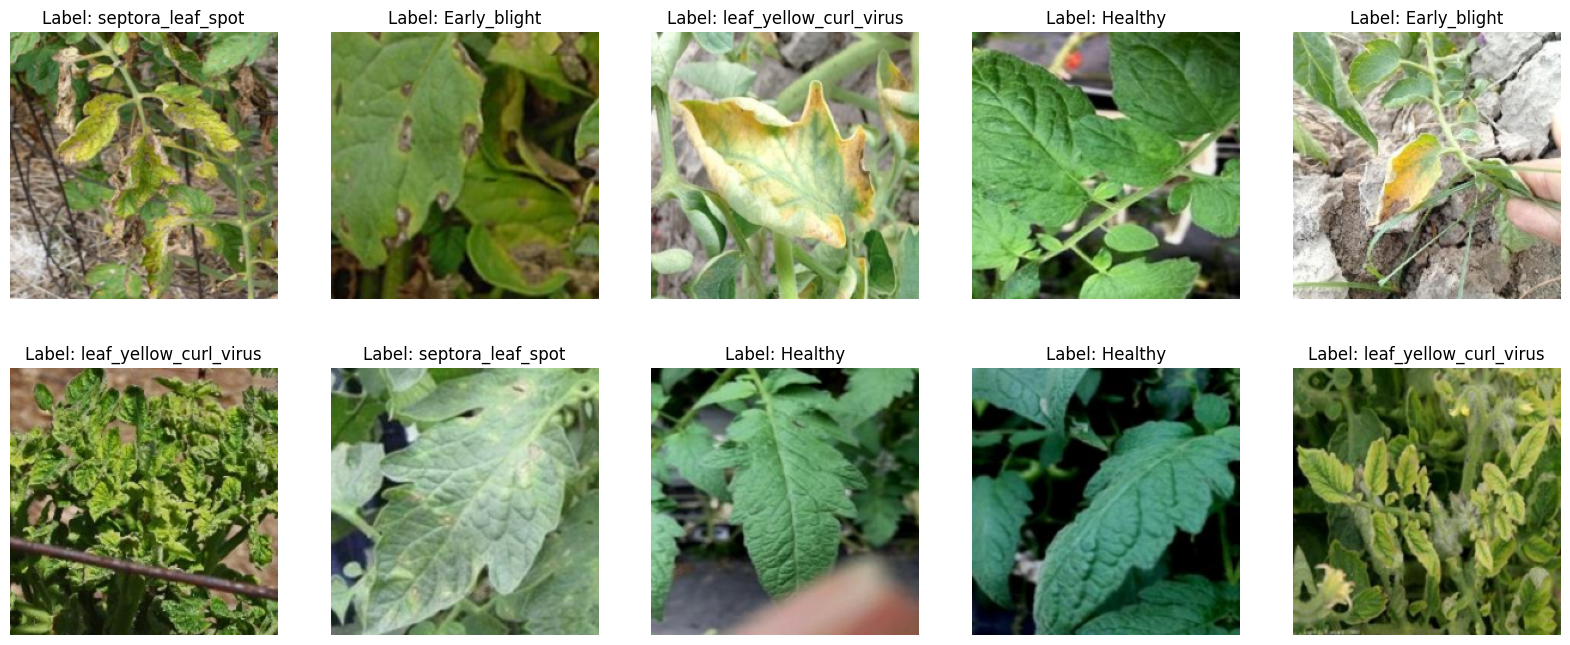

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

 #class names
classes = ["Early_blight","Healthy","leaf_late_blight","leaf_yellow_curl_virus","mold_leaf","septora_leaf_spot"]

# Show images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = np.transpose(img.numpy(), (1, 2, 0))# Convert (C, H, W) to (H, W, C)
    img_denorm=img_denormlized(img)
    img_denorm=img_denorm.clip(0,1)
    ax.imshow(img_denorm)
    ax.set_title(f"Label: {classes[labels[i].item()]}")
    ax.axis("off")

plt.show()

In [45]:
# i will use pre trained model efficientnet_v2_s
from torchvision.models import efficientnet_v2_s
model =efficientnet_v2_s(pretrained=True)
model.classifier[1]=nn.Linear(model.classifier[1].in_features,6)
# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 186MB/s]


In [54]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels
        labels=labels.to(device)


        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)  # Get class with highest probability
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels
            labels=labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy


In [47]:

import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 6 # Number of epochs
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

100%|██████████| 180/180 [01:31<00:00,  1.96it/s]


Epoch 1/6: Train Loss=0.5390, Train Accuracy=82.38%, Val Loss=0.3151, Val Accuracy=91.46%


100%|██████████| 180/180 [01:22<00:00,  2.18it/s]


Epoch 2/6: Train Loss=0.2503, Train Accuracy=92.36%, Val Loss=0.1714, Val Accuracy=95.42%


100%|██████████| 180/180 [01:23<00:00,  2.15it/s]


...

Epoch 4/6: Train Loss=0.1321, Train Accuracy=95.95%, Val Loss=0.1799, Val Accuracy=94.10%


100%|██████████| 180/180 [01:23<00:00,  2.17it/s]


Epoch 5/6: Train Loss=0.1465, Train Accuracy=95.14%, Val Loss=0.1417, Val Accuracy=96.25%


100%|██████████| 180/180 [01:23<00:00,  2.16it/s]


Epoch 6/6: Train Loss=0.1114, Train Accuracy=96.46%, Val Loss=0.1152, Val Accuracy=96.11%


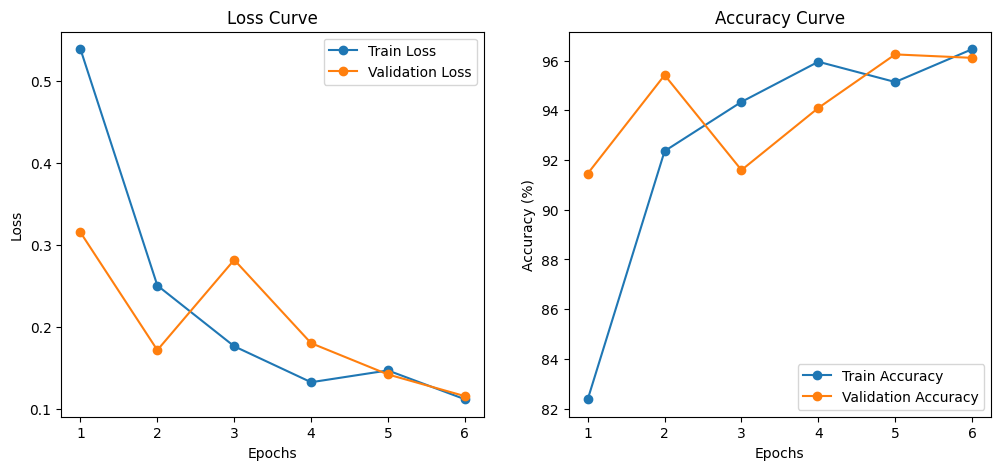

In [55]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()